In [16]:
#!pip install pandas
#!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import torch
from pathlib import Path

# Acceleration Data

In [3]:
results = pd.DataFrame([
    ["FFT", "16x16", 6856385, 3918681, 4663524, 1797893, 1.749666533],
    ["FFT", "32x32", 30311270, 3918681, 20660964, 1797893, 7.73506953],
    ["FFT", "64x64", 135331395, 34788075, 91326749, 14908647, 3.890166242],

    ["Gemmini", "16x16", 1783900, 8546, 1274919, 1327, 208.7409314],
    ["Gemmini", "32x32", 7148014, 22853, 5099559, 2382, 312.7823043],
    ["Gemmini", "64x64", 31391101, 79844, 20398119, 5392, 393.1554156],

    ["RV-SCNN", "16x16", 1597004, 499942, 1118241, 323512, 3.194378548],
    ["RV-SCNN", "32x32", 5873739, 1999079, 4472865, 1293496, 2.938222551],
    ["RV-SCNN", "64x64", 25550930, 7995624, 17891366, 5173432, 3.195614251],
], columns=[
    "accelerator",
    "resolution",
    "cycles_unaccel",
    "cycles_accel",
    "inst_unaccel",
    "inst_accel",
    "speedup"
])

square_gemm = pd.DataFrame({
    "size": ["4x4", "8x8", "16x16", "32x32"],

    # RV-SCNN — total (existing)
    "rvscnn_accel_instructions": [1798, 10387, 69565, 505105],
    "rvscnn_accel_cycles":       [2541, 14601, 97275, 703815],
    "rvscnn_unaccel_instructions": [3415, 24771, 190747, 1499595],
    "rvscnn_unaccel_cycles":       [4871, 35035, 268451, 2105011],
    "rvscnn_speedup": [1.916961826, 2.399493185, 2.759712156, 2.990858393],

    # RV-SCNN — accelerator-only (new)
    "rvscnn_accel_only_instructions": [140,  560,  2240,  8960],
    "rvscnn_accel_only_cycles":       [241,  872,  3744, 17024],
    "rvscnn_accel_only_speedup": [20.21161826, 40.17775229, 71.70165598, 123.6496123],

    # Gemmini — total (existing)
    "gemmini_accel_instructions": [799,  5043,  36283,  275787],
    "gemmini_accel_cycles":       [1156, 7536,  54264,  411634],
    "gemmini_unaccel_instructions": [419, 419, 419, 419],
    "gemmini_unaccel_cycles":       [614, 629, 670, 1006],
    "gemmini_speedup": [1.882736156, 11.9809221, 80.99104478, 409.1789264],

    # Gemmini — accelerator-only (new)
    "gemmini_accel_only_speedup": [1.882736156, 11.9809221, 80.99104478, 409.1789264],
})



# Model

In [4]:
training_metrics = pd.DataFrame({
    "epoch": list(range(1, 16)),
    "train_h1": [
        51.496668, 31.910141, 25.115520, 20.574472, 18.324536,
        16.063087, 14.613394, 14.668927, 13.210583, 12.577862,
        12.760916, 12.534035, 12.006013, 11.424158, 11.095783
    ],
    "test_16_h1": [
        0.586775, 0.457827, 0.350696, 0.312273, 0.283596,
        0.254185, 0.239733, 0.228477, 0.214315, 0.215284,
        0.207852, 0.204088, 0.203268, 0.192498, 0.191212
    ],
    "test_16_l2": [
        0.407750, 0.291306, 0.233697, 0.221533, 0.195779,
        0.178352, 0.167583, 0.162201, 0.151948, 0.151323,
        0.145528, 0.141250, 0.140002, 0.130399, 0.127213
    ],
    "test_32_h1": [
        0.657383, 0.530706, 0.439169, 0.423526, 0.378755,
        0.367663, 0.349103, 0.346036, 0.342781, 0.333112,
        0.344912, 0.344831, 0.328490, 0.328917, 0.322749
    ],
    "test_32_l2": [
        0.388987, 0.279500, 0.225763, 0.223183, 0.197376,
        0.184297, 0.175840, 0.170965, 0.167379, 0.162422,
        0.164583, 0.162760, 0.153585, 0.148278, 0.143767
    ]
})

# Extrapolations to Full FNO

In [5]:
fno_acceleration = pd.DataFrame({
    "module": [
        "conv1d",
        "gelu",
        "einsum",
        "fft_cumulative",
        "rfftn",
        "ifftn",
        "irfftn",
        "others"
    ],

    # Original profile
    "base_16": [26.3893, 9.8735, 9.6724, 17.8654, 6.4864, 6.1312, 5.2478, 36.1994],
    "base_32": [17.6255, 13.6950, 11.8197, 17.1242, 5.2478, 5.9246, 5.9518, 39.7356],

    # FFT + Gemmini
    "fft_gemmini_16": [0.1264213004, 9.8735, 9.6724, 10.21074568, 3.707220706, 3.504210593, 2.999314384, 36.1994],
    "fft_gemmini_32": [0.05635069426, 13.6950, 11.8197, 2.213839182, 0.6784425117, 0.7659401092, 0.7694565611, 39.7356],

    # FFT + RV-SCNN
    "fft_rvscnn_16": [8.261168676, 9.8735, 9.6724, 10.21074568, 3.707220706, 3.504210593, 2.999314384, 36.1994],
    "fft_rvscnn_32": [5.998694684, 13.6950, 11.8197, 2.213839182, 0.6784425117, 0.7659401092, 0.7694565611, 39.7356],

    # Gemmini only
    "gemmini_16": [0.1264213004, 9.8735, 9.6724, 17.8654, 6.4864, 6.1312, 5.2478, 36.1994],
    "gemmini_32": [0.05635069426, 13.6950, 11.8197, 17.1242, 5.2478, 5.9246, 5.9518, 39.7356],

    # RV-SCNN only
    "rvscnn_16": [8.261168676, 9.8735, 9.6724, 17.8654, 6.4864, 6.1312, 5.2478, 36.1994],
    "rvscnn_32": [5.998694684, 13.6950, 11.8197, 17.1242, 5.2478, 5.9246, 5.9518, 39.7356],

    # FFT only
    "fft_only_16": [26.3893, 9.8735, 9.6724, 5.592762327, 2.030567105, 1.919371768, 1.642823454, 36.1994],
    "fft_only_32": [17.6255, 13.6950, 11.8197, 5.828081331, 1.786045784, 2.016389125, 2.025646423, 39.7356],
})

fno_speedups = pd.DataFrame({
    "Speedup": ["FFT", "RV-SCNN", "GEMMINI", "RV-SCNN + FFT", "GEMMINI + FFT"],
    "16": [1.139895209, 1.221420759, 1.356169026, 1.3473963, 1.513260696],
    "32": [1.127346386, 1.131564841, 1.213138032, 1.361232541, 1.481031909]
})

# figures

# Model Training

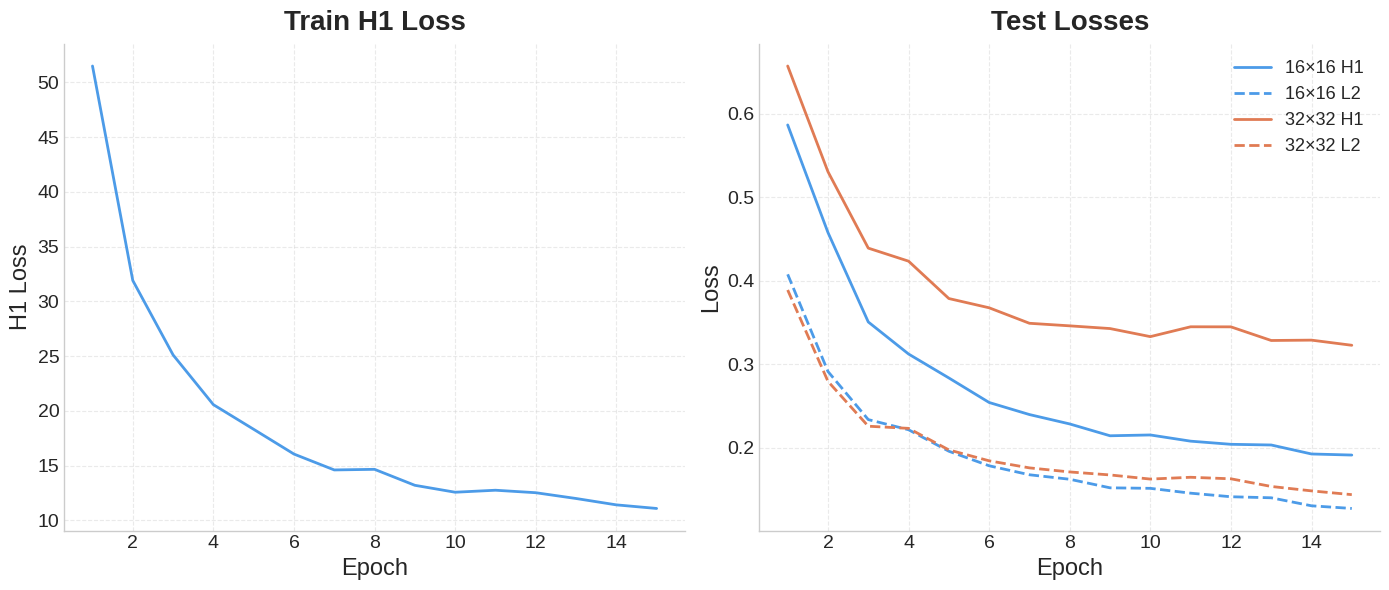

In [21]:
# ── DATAFRAME ────────────────────────────────────────────────────────────────
temp = training_metrics[["epoch", "train_h1", "test_16_h1", "test_16_l2", "test_32_h1", "test_32_l2"]].copy()

# ── GRAPH ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

FS_TITLE  = 20
FS_LABEL  = 17
FS_TICK   = 14
FS_LEGEND = 13

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Train H1 loss ───────────────────────────────────────────────────────
ax1.plot(temp["epoch"], temp["train_h1"], color="#4C9BE8", linewidth=2)
ax1.set_title("Train H1 Loss", fontsize=FS_TITLE, fontweight="bold", pad=10)
ax1.set_xlabel("Epoch", fontsize=FS_LABEL)
ax1.set_ylabel("H1 Loss", fontsize=FS_LABEL)
ax1.tick_params(labelsize=FS_TICK)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(linestyle="--", alpha=0.4)

# ── Right: Test losses ────────────────────────────────────────────────────────
ax2.plot(temp["epoch"], temp["test_16_h1"], color="#4C9BE8", linestyle="-",  linewidth=2, label="16×16 H1")
ax2.plot(temp["epoch"], temp["test_16_l2"], color="#4C9BE8", linestyle="--", linewidth=2, label="16×16 L2")
ax2.plot(temp["epoch"], temp["test_32_h1"], color="#E07B54", linestyle="-",  linewidth=2, label="32×32 H1")
ax2.plot(temp["epoch"], temp["test_32_l2"], color="#E07B54", linestyle="--", linewidth=2, label="32×32 L2")
ax2.set_title("Test Losses", fontsize=FS_TITLE, fontweight="bold", pad=10)
ax2.set_xlabel("Epoch", fontsize=FS_LABEL)
ax2.set_ylabel("Loss", fontsize=FS_LABEL)
ax2.tick_params(labelsize=FS_TICK)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(linestyle="--", alpha=0.4)
ax2.legend(fontsize=FS_LEGEND)

plt.tight_layout()
plt.savefig("./figures/model_training_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## FFT Instructions/Cycles

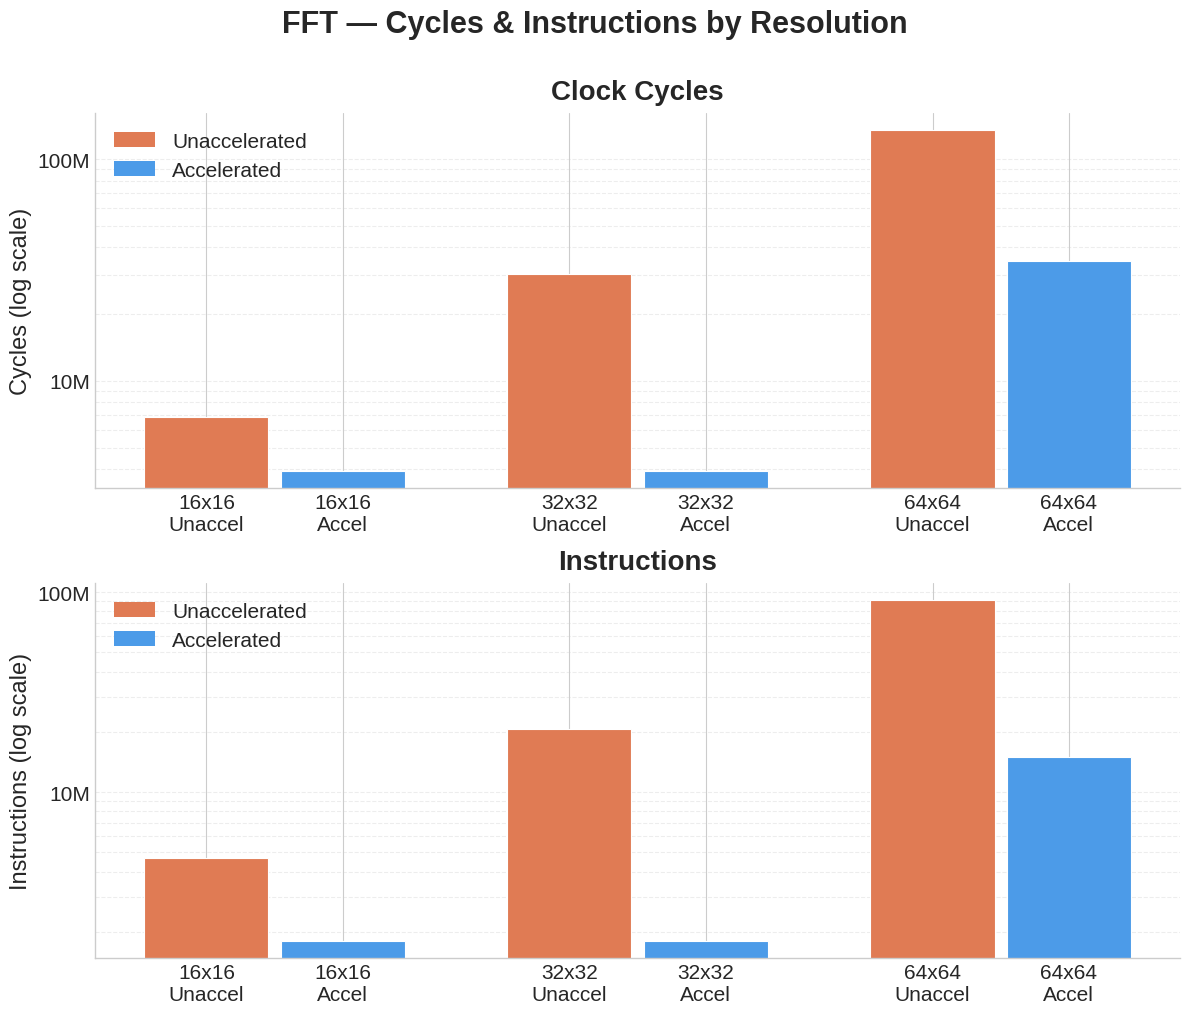

In [22]:
temp = results[results["accelerator"] == "FFT"][
    ["resolution", "cycles_unaccel", "cycles_accel", "inst_unaccel", "inst_accel"]
].reset_index(drop=True)

UNACCEL_COLOR = "#E07B54"
ACCEL_COLOR   = "#4C9BE8"
BAR_WIDTH     = 0.82
FS_TITLE      = 20
FS_LABEL      = 17
FS_TICK       = 15
FS_LEGEND     = 15

x_positions = np.array([0, 0.9, 2.4, 3.3, 4.8, 5.7])
labels       = [f"{r}\n{t}" for r in temp["resolution"] for t in ("Unaccel", "Accel")]
colors       = [UNACCEL_COLOR, ACCEL_COLOR] * len(temp)
legend_els   = [Patch(facecolor=UNACCEL_COLOR, label="Unaccelerated"),
                Patch(facecolor=ACCEL_COLOR,   label="Accelerated")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("FFT — Cycles & Instructions by Resolution", fontsize=22, fontweight="bold", y=1.01)

for ax, col_u, col_a, title, ylabel in [
    (ax1, "cycles_unaccel", "cycles_accel", "Clock Cycles",  "Cycles (log scale)"),
    (ax2, "inst_unaccel",   "inst_accel",   "Instructions",  "Instructions (log scale)"),
]:
    vals = [v for _, row in temp.iterrows() for v in (row[col_u], row[col_a])]
    ax.bar(x_positions, vals, width=BAR_WIDTH, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=FS_TICK)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else (f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}")
    ))
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")
    ax.legend(handles=legend_els, loc="upper left", fontsize=FS_LEGEND)

plt.tight_layout()
plt.savefig(f"./figures/fft_acceleration_rawdata.png", dpi=150, bbox_inches="tight")
plt.show()

## RVSCNN Instructions/Cycles

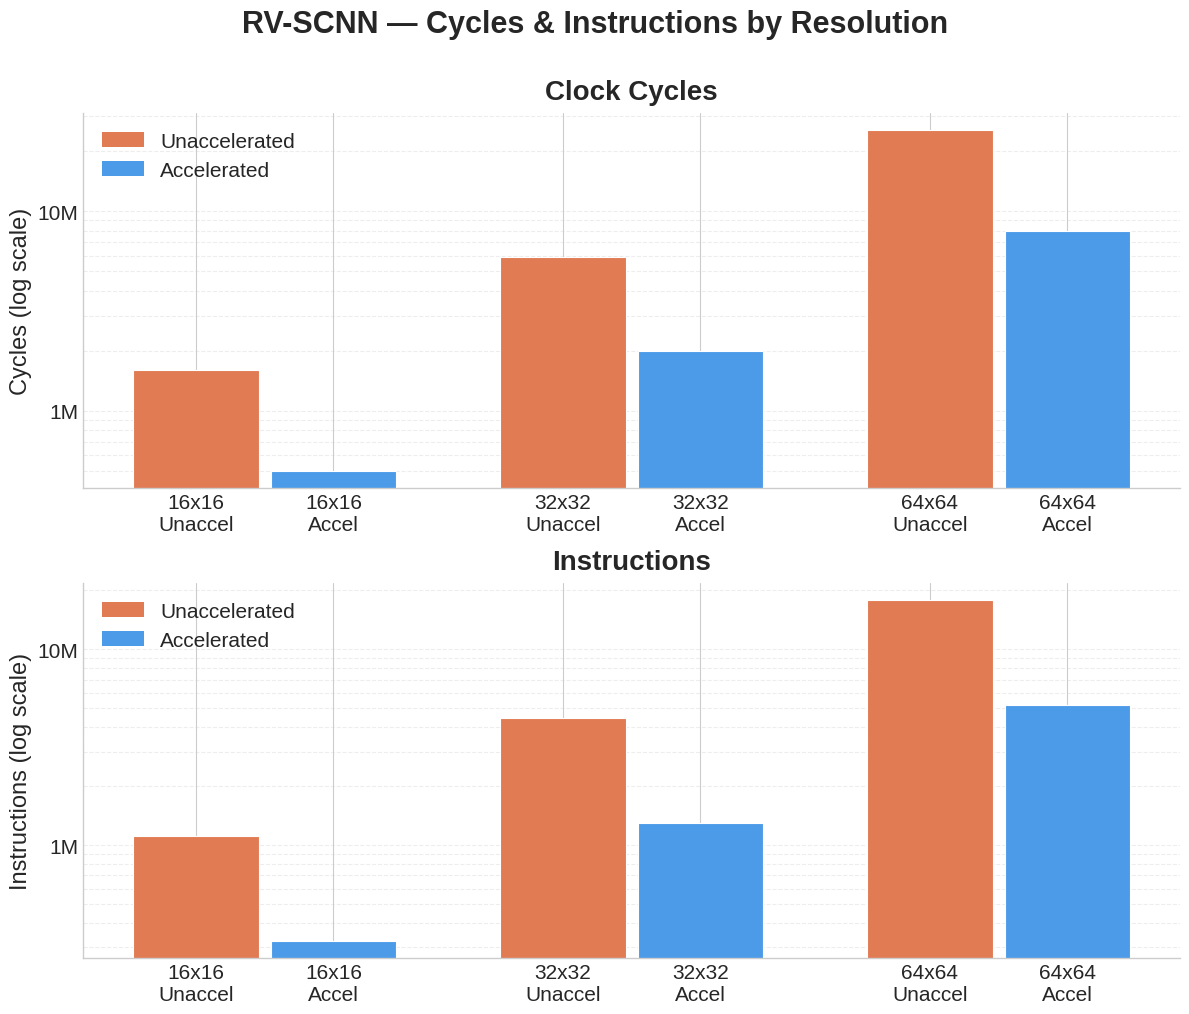

In [23]:

temp = results[results["accelerator"] == "RV-SCNN"][
    ["resolution", "cycles_unaccel", "cycles_accel", "inst_unaccel", "inst_accel"]
].reset_index(drop=True)

UNACCEL_COLOR = "#E07B54"
ACCEL_COLOR   = "#4C9BE8"
BAR_WIDTH     = 0.82
FS_TITLE      = 20
FS_LABEL      = 17
FS_TICK       = 15
FS_LEGEND     = 15

x_positions = np.array([0, 0.9, 2.4, 3.3, 4.8, 5.7])
labels       = [f"{r}\n{t}" for r in temp["resolution"] for t in ("Unaccel", "Accel")]
colors       = [UNACCEL_COLOR, ACCEL_COLOR] * len(temp)
legend_els   = [Patch(facecolor=UNACCEL_COLOR, label="Unaccelerated"),
                Patch(facecolor=ACCEL_COLOR,   label="Accelerated")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("RV-SCNN — Cycles & Instructions by Resolution", fontsize=22, fontweight="bold", y=1.01)

for ax, col_u, col_a, title, ylabel in [
    (ax1, "cycles_unaccel", "cycles_accel", "Clock Cycles",  "Cycles (log scale)"),
    (ax2, "inst_unaccel",   "inst_accel",   "Instructions",  "Instructions (log scale)"),
]:
    vals = [v for _, row in temp.iterrows() for v in (row[col_u], row[col_a])]
    ax.bar(x_positions, vals, width=BAR_WIDTH, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=FS_TICK)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else (f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}")
    ))
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")
    ax.legend(handles=legend_els, loc="upper left", fontsize=FS_LEGEND)

plt.tight_layout()
plt.savefig(f"./figures/rvscnn_acceleration_rawdata.png", dpi=150, bbox_inches="tight")
plt.show()

## Gemmini Instructions/Cycles

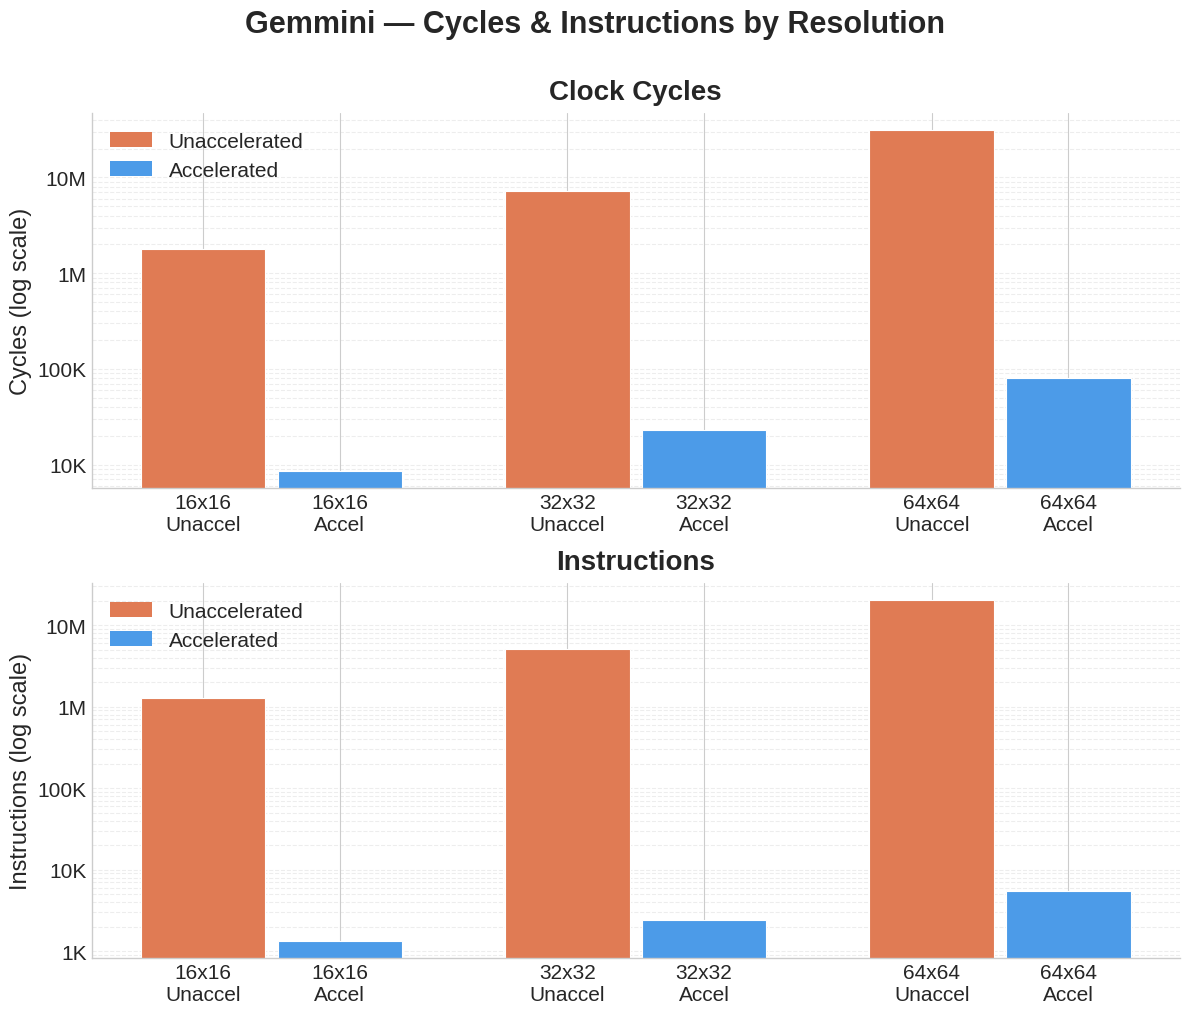

In [24]:
temp = results[results["accelerator"] == "Gemmini"][
    ["resolution", "cycles_unaccel", "cycles_accel", "inst_unaccel", "inst_accel"]
].reset_index(drop=True)


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

UNACCEL_COLOR = "#E07B54"
ACCEL_COLOR   = "#4C9BE8"
BAR_WIDTH     = 0.82
FS_TITLE      = 20
FS_LABEL      = 17
FS_TICK       = 15
FS_LEGEND     = 15

x_positions = np.array([0, 0.9, 2.4, 3.3, 4.8, 5.7])
labels       = [f"{r}\n{t}" for r in temp["resolution"] for t in ("Unaccel", "Accel")]
colors       = [UNACCEL_COLOR, ACCEL_COLOR] * len(temp)
legend_els   = [Patch(facecolor=UNACCEL_COLOR, label="Unaccelerated"),
                Patch(facecolor=ACCEL_COLOR,   label="Accelerated")]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Gemmini — Cycles & Instructions by Resolution", fontsize=22, fontweight="bold", y=1.01)

for ax, col_u, col_a, title, ylabel in [
    (ax1, "cycles_unaccel", "cycles_accel", "Clock Cycles",  "Cycles (log scale)"),
    (ax2, "inst_unaccel",   "inst_accel",   "Instructions",  "Instructions (log scale)"),
]:
    vals = [v for _, row in temp.iterrows() for v in (row[col_u], row[col_a])]
    ax.bar(x_positions, vals, width=BAR_WIDTH, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=FS_TICK)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else (f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}")
    ))
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")
    ax.legend(handles=legend_els, loc="upper left", fontsize=FS_LEGEND)

plt.tight_layout()
plt.savefig(f"./figures/gemmini_acceleration_rawdata.png", dpi=150, bbox_inches="tight")
plt.show()

## Speedup figures

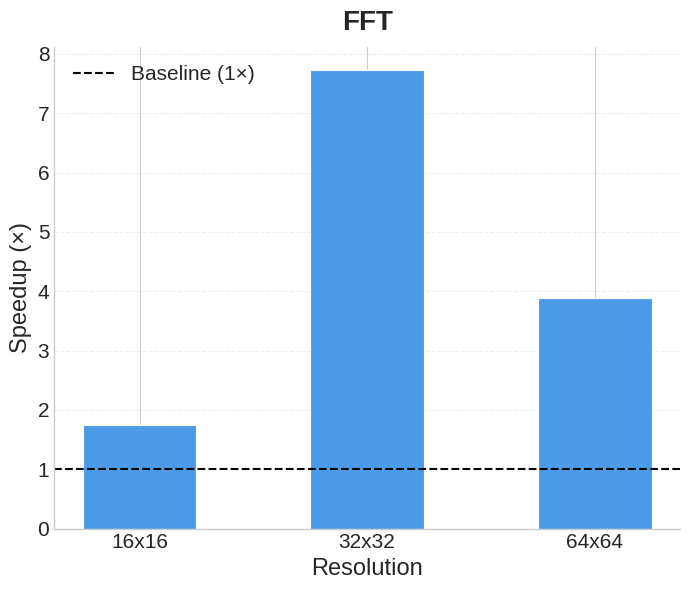

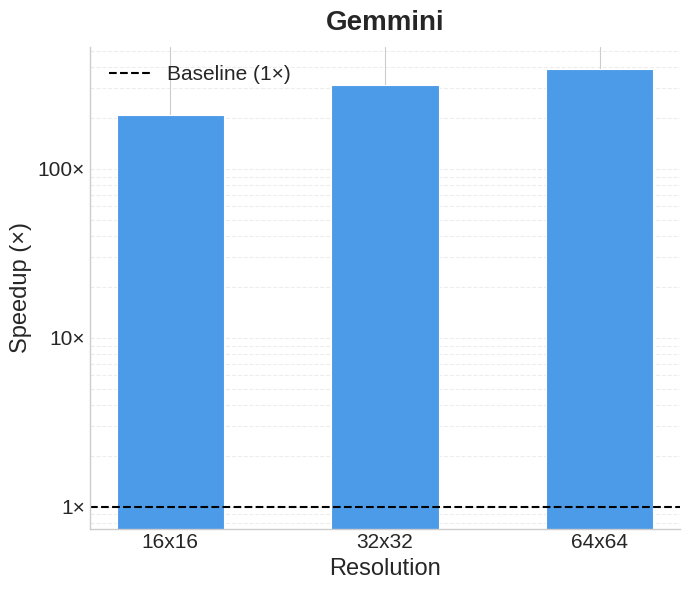

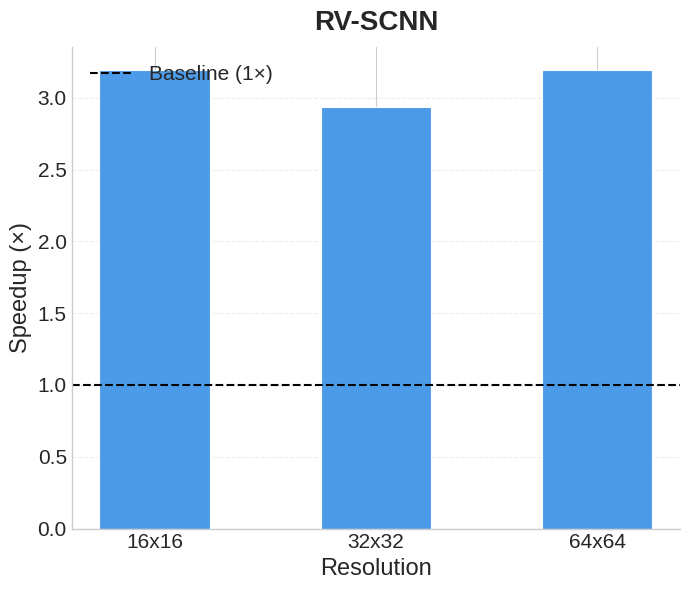

In [25]:
# ── DATAFRAME ────────────────────────────────────────────────────────────────
temp_fft     = results[results["accelerator"] == "FFT"][["resolution", "speedup"]].reset_index(drop=True)
temp_gemmini = results[results["accelerator"] == "Gemmini"][["resolution", "speedup"]].reset_index(drop=True)
temp_rvscnn  = results[results["accelerator"] == "RV-SCNN"][["resolution", "speedup"]].reset_index(drop=True)

# ── GRAPH ─────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BAR_COLOR   = "#4C9BE8"
BAR_WIDTH   = 0.5
FS_TITLE    = 20
FS_LABEL    = 17
FS_TICK     = 15
FS_LEGEND   = 15
resolutions = ["16x16", "32x32", "64x64"]
x           = np.arange(3)

for temp, title, log_scale in [
    (temp_fft,     "FFT",     False),
    (temp_gemmini, "Gemmini", True),
    (temp_rvscnn,  "RV-SCNN", False),
]:
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.bar(x, temp["speedup"].values, width=BAR_WIDTH, color=BAR_COLOR, edgecolor="white", linewidth=0.8)
    ax.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Baseline (1×)")
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=12)
    ax.set_xlabel("Resolution", fontsize=FS_LABEL)
    ax.set_ylabel("Speedup (×)", fontsize=FS_LABEL)
    ax.set_xticks(x)
    ax.set_xticklabels(resolutions, fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, which="both" if log_scale else "major")
    ax.legend(fontsize=FS_LEGEND, loc="upper left")

    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:.0f}×"
        ))
    
    plt.tight_layout()
    plt.savefig(f"./figures/{title.lower().replace('-', '')}_speedups.png", dpi=150, bbox_inches="tight")
    plt.show()

## Full FNO figures

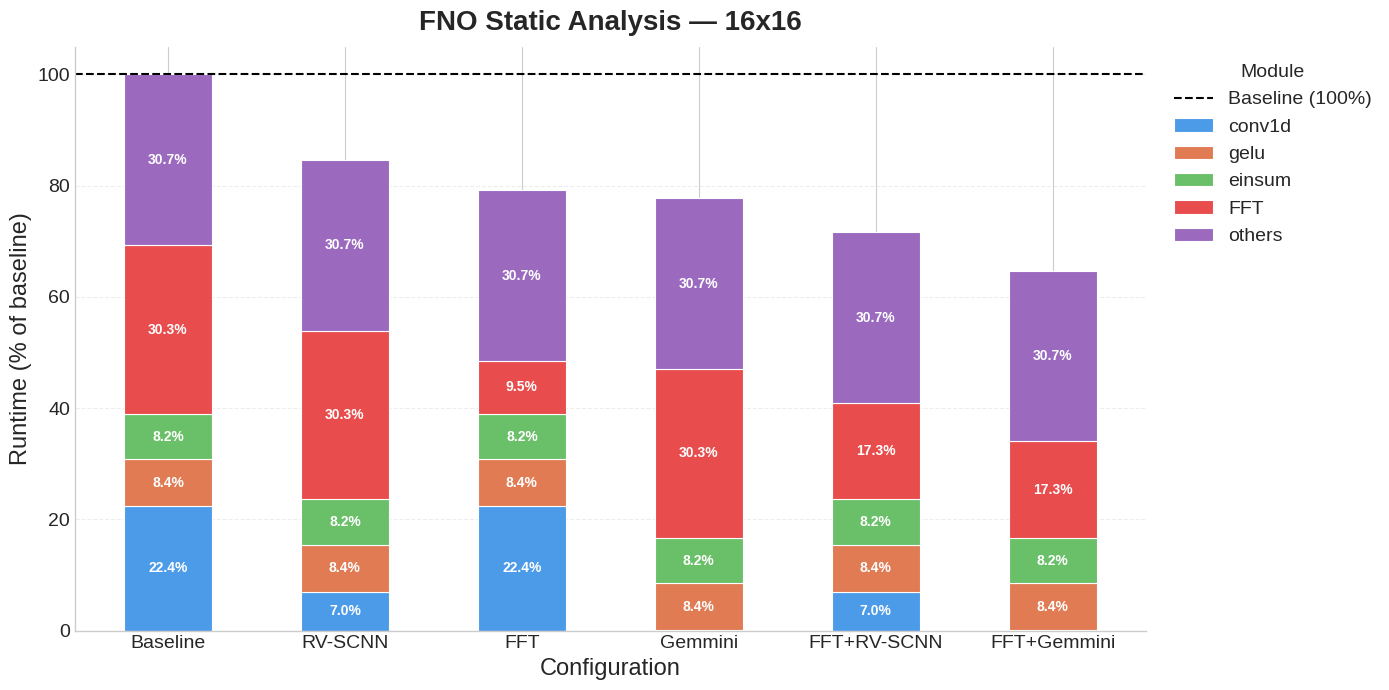

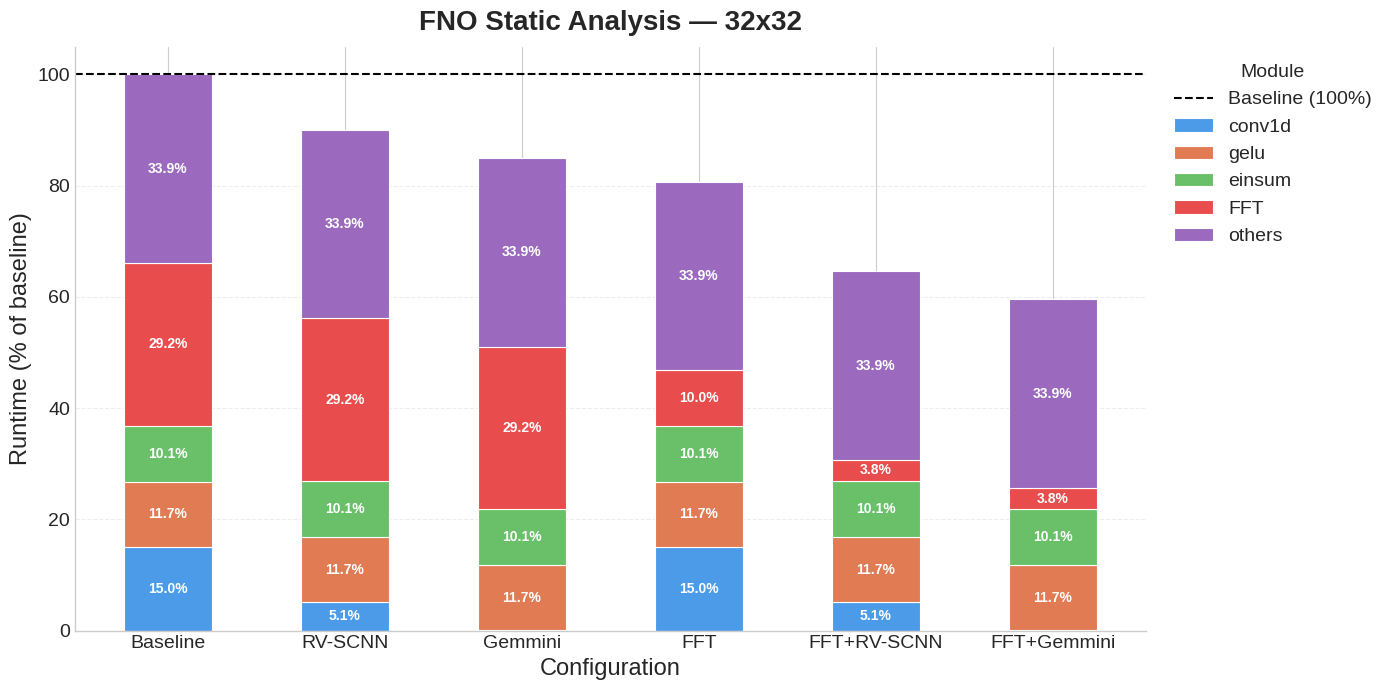

In [26]:
# ── DATAFRAME ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def build_temp(fno_acceleration, suffix):
    fft_modules = ["fft_cumulative", "rfftn", "ifftn", "irfftn"]
    configs = ["baseline", "fft_only", "gemmini", "rvscnn", "fft_gemmini", "fft_rvscnn"]
    col_map = {
        "baseline":    f"base_{suffix}",
        "fft_only":    f"fft_only_{suffix}",
        "gemmini":     f"gemmini_{suffix}",
        "rvscnn":      f"rvscnn_{suffix}",
        "fft_gemmini": f"fft_gemmini_{suffix}",
        "fft_rvscnn":  f"fft_rvscnn_{suffix}",
    }
    baseline_total = fno_acceleration[f"base_{suffix}"].sum()

    rows = []
    for module_group, label in [
        (["conv1d"],  "conv1d"),
        (["gelu"],    "gelu"),
        (["einsum"],  "einsum"),
        (fft_modules, "FFT"),
        (["others"],  "others"),
    ]:
        row = {"module": label}
        for cfg, col in col_map.items():
            row[cfg] = fno_acceleration.loc[fno_acceleration["module"].isin(module_group), col].sum() / baseline_total * 100
        rows.append(row)
    return pd.DataFrame(rows), baseline_total

# ── GRAPH ─────────────────────────────────────────────────────────────────────
COLORS        = ["#4C9BE8", "#E07B54", "#6ABF69", "#E84C4C", "#9B6ABF"]
MODULES       = ["conv1d", "gelu", "einsum", "FFT", "others"]
CONFIGS       = ["baseline", "fft_only", "gemmini", "rvscnn", "fft_gemmini", "fft_rvscnn"]
CONFIG_LABELS = ["Baseline", "FFT", "Gemmini", "RV-SCNN", "FFT+Gemmini", "FFT+RV-SCNN"]
FS_TITLE      = 20
FS_LABEL      = 17
FS_TICK       = 14
FS_LEGEND     = 14
FS_ANNOT      = 10

for suffix, res_label in [("16", "16x16"), ("32", "32x32")]:
    temp, baseline_total = build_temp(fno_acceleration, suffix)

    # Sort configs by total runtime descending
    totals = temp[CONFIGS].sum(axis=0)
    order  = totals.sort_values(ascending=False).index.tolist()
    config_label_map = dict(zip(CONFIGS, CONFIG_LABELS))
    sorted_labels = [config_label_map[c] for c in order]

    fig, ax = plt.subplots(figsize=(14, 7))

    bottoms = np.zeros(len(order))
    for module, color in zip(MODULES, COLORS):
        vals = temp.set_index("module").loc[module, order].values.astype(float)
        ax.bar(sorted_labels, vals, bottom=bottoms, color=color,
               edgecolor="white", linewidth=0.8, label=module, width=0.5)
        for j, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 3.0:
                ax.text(j, b + v / 2, f"{v:.1f}%",
                        ha="center", va="center", fontsize=FS_ANNOT,
                        color="white", fontweight="bold")
        bottoms += vals

    ax.axhline(100, color="black", linestyle="--", linewidth=1.5, label="Baseline (100%)")

    ax.set_title(f"FNO Static Analysis — {res_label}", fontsize=FS_TITLE, fontweight="bold", pad=12)
    ax.set_xlabel("Configuration", fontsize=FS_LABEL)
    ax.set_ylabel("Runtime (% of baseline)", fontsize=FS_LABEL)
    ax.tick_params(axis="x", labelsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(title="Module", fontsize=FS_LEGEND, title_fontsize=FS_LEGEND,
              bbox_to_anchor=(1.01, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(f"figures/fno_composition_{suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()

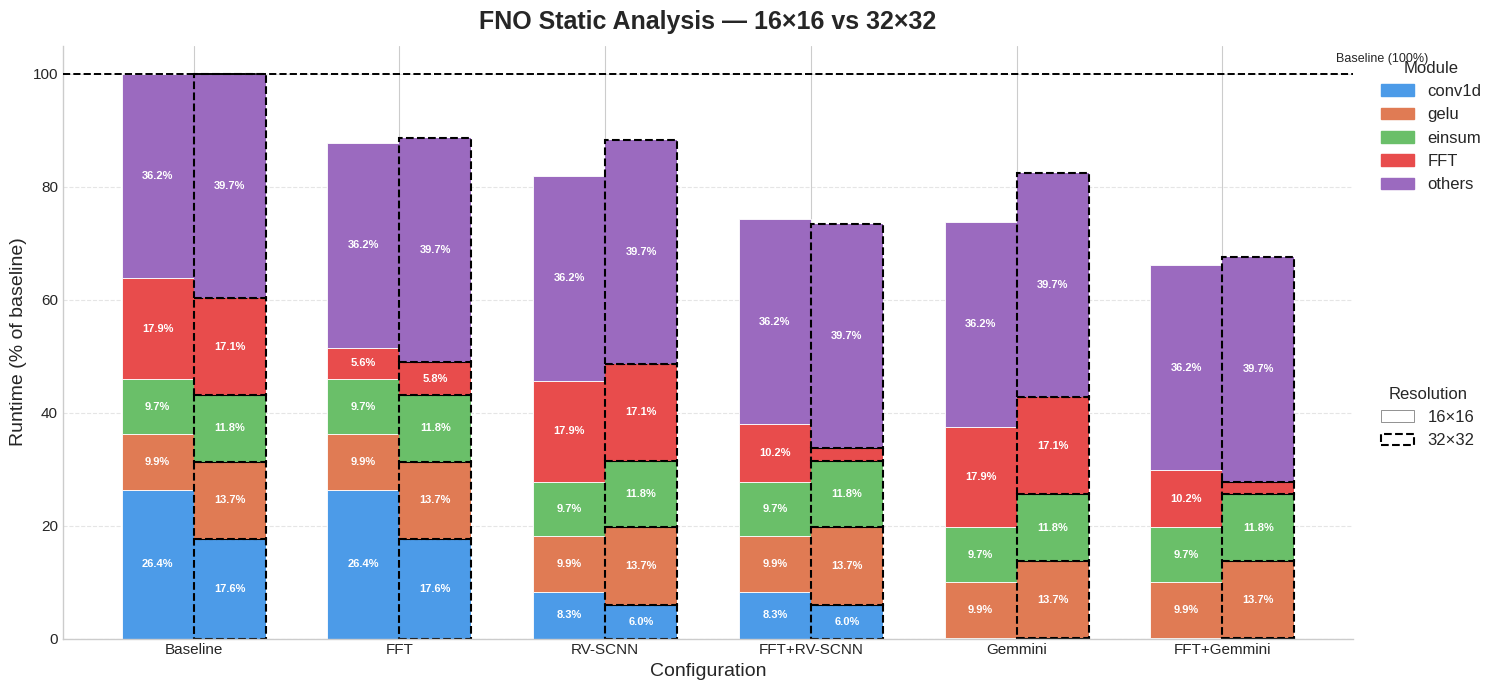

Saved to fno_composition_combined_style_edge.png


In [27]:
def build_temp(fno_acceleration, suffix):
    """Parses dataframe, normalizes against a clean baseline sum, and aggregates groups."""
    fft_modules = ["fft_cumulative", "rfftn", "ifftn", "irfftn"]
    configs = ["baseline", "fft_only", "gemmini", "rvscnn", "fft_gemmini", "fft_rvscnn"]
    col_map = {
        "baseline":    f"base_{suffix}",
        "fft_only":    f"fft_only_{suffix}",
        "gemmini":     f"gemmini_{suffix}",
        "rvscnn":      f"rvscnn_{suffix}",
        "fft_gemmini": f"fft_gemmini_{suffix}",
        "fft_rvscnn":  f"fft_rvscnn_{suffix}",
    }
    
    # Filter 'fft_cumulative' out of baseline sum calculation to avoid double-counting.
    true_base_rows = fno_acceleration[fno_acceleration["module"] != "fft_cumulative"]
    baseline_total = true_base_rows[f"base_{suffix}"].sum()
    
    rows = []
    for module_group, label in [
        (["conv1d"],  "conv1d"),
        (["gelu"],    "gelu"),
        (["einsum"],  "einsum"),
        # Breakdown of individual FFT components
        (["rfftn", "ifftn", "irfftn"], "FFT"), 
        (["others"],  "others"),
    ]:
        row = {"module": label}
        for cfg, col in col_map.items():
            row[cfg] = fno_acceleration.loc[
                fno_acceleration["module"].isin(module_group), col
            ].sum() / baseline_total * 100
        rows.append(row)
    return pd.DataFrame(rows), baseline_total

# ── SETTINGS ──────────────────────────────────────────────────────────────────
COLORS        = ["#4C9BE8", "#E07B54", "#6ABF69", "#E84C4C", "#9B6ABF"]
MODULES       = ["conv1d", "gelu", "einsum", "FFT", "others"]
CONFIGS       = ["baseline", "fft_only", "gemmini", "rvscnn", "fft_gemmini", "fft_rvscnn"]
CONFIG_LABELS = ["Baseline", "FFT", "Gemmini", "RV-SCNN", "FFT+Gemmini", "FFT+RV-SCNN"]
RESOLUTIONS   = [("16", "16×16"), ("32", "32×32")]

FS_TITLE  = 18
FS_LABEL  = 14
FS_TICK   = 11
FS_LEGEND = 12
FS_ANNOT  = 8

# ── BUILD DATA FOR BOTH RESOLUTIONS ──────────────────────────────────────────
temps = {}
for suffix, _ in RESOLUTIONS:
    temps[suffix], _ = build_temp(fno_acceleration, suffix)

# Order configurations based on the baseline composition totals (16x16)
totals_16 = temps["16"][CONFIGS].sum(axis=0)
order = totals_16.sort_values(ascending=False).index.tolist()
sorted_labels = [CONFIG_LABELS[CONFIGS.index(c)] for c in order]

n_configs = len(order)
n_res     = len(RESOLUTIONS)
group_width = 0.7          # total width allocated per config group
bar_width   = group_width / n_res
x = np.arange(n_configs)  # center of each group

# ── PLOT ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(15, 7))

for r_idx, (suffix, res_label) in enumerate(RESOLUTIONS):
    temp = temps[suffix]
    offset = (r_idx - (n_res - 1) / 2) * bar_width
    bottoms = np.zeros(n_configs)

    for m_idx, (module, color) in enumerate(zip(MODULES, COLORS)):
        vals = temp.set_index("module").loc[module, order].values.astype(float)

        # CHANGE: Edge Variation is applied here. Hatching is removed.
        alpha = 1.0
        hatch = "" # Pattern removed
        
        # Style 16x16 (Thin white border) vs 32x32 (Thick dashed black border)
        if r_idx == 1:
            edge_color = "black"
            line_style = "--"
            line_width = 1.5
        else:
            edge_color = "white"
            line_style = "-"
            line_width = 0.6

        bars = ax.bar(
            x + offset, vals, bottom=bottoms,
            width=bar_width,
            color=color, alpha=alpha,
            hatch=hatch,
            # Applied New Style
            edgecolor=edge_color, linestyle=line_style, linewidth=line_width,
        )

        # Annotate segments large enough to label
        for j, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 4.0:
                ax.text(
                    x[j] + offset, b + v / 2,
                    f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=FS_ANNOT, color="white", fontweight="bold"
                )
        bottoms += vals

# ── BASELINE LINE ─────────────────────────────────────────────────────────────
ax.axhline(100, color="black", linestyle="--", linewidth=1.4, zorder=5)
ax.text(n_configs - 0.45, 101.5, "Baseline (100%)", fontsize=FS_ANNOT + 1, va="bottom")

# ── LEGEND: modules + resolution style breakdown ─────────────────────────────
module_patches = [
    mpatches.Patch(color=c, label=m) for m, c in zip(MODULES, COLORS)
]

# UPDATED: Legend patches illustrate the difference in edge styles.
res_patches = [
    mpatches.Patch(facecolor="white", edgecolor="grey", linewidth=0.6, linestyle="-", label="16×16"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=1.5, linestyle="--", label="32×32"),
]
legend1 = ax.legend(
    handles=module_patches,
    title="Module", fontsize=FS_LEGEND, title_fontsize=FS_LEGEND,
    bbox_to_anchor=(1.01, 1), loc="upper left"
)
ax.add_artist(legend1)
ax.legend(
    handles=res_patches,
    title="Resolution", fontsize=FS_LEGEND, title_fontsize=FS_LEGEND,
    bbox_to_anchor=(1.01, 0.45), loc="upper left"
)

# ── AXES FORMATTING ───────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, fontsize=FS_TICK)
ax.set_xlabel("Configuration", fontsize=FS_LABEL)
ax.set_ylabel("Runtime (% of baseline)", fontsize=FS_LABEL)
ax.set_title("FNO Static Analysis — 16×16 vs 32×32", fontsize=FS_TITLE, fontweight="bold", pad=12)
ax.tick_params(axis="y", labelsize=FS_TICK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("figures/fno_composition_combined_style_edge.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to fno_composition_combined_style_edge.png")

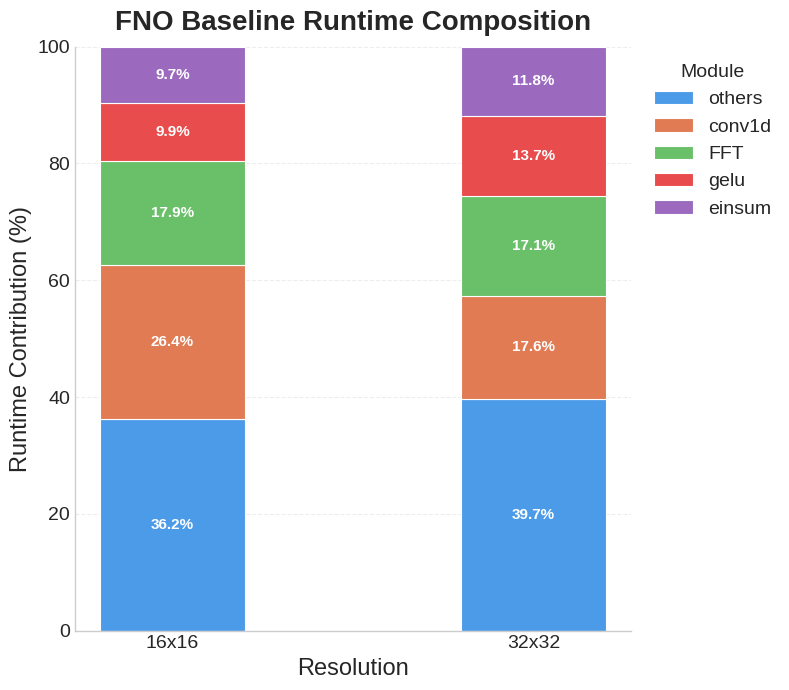

In [28]:
# ── DATAFRAME ────────────────────────────────────────────────────────────────
import pandas as pd

temp = pd.DataFrame({
    "module": ["conv1d", "gelu", "einsum", "FFT", "others"],
    "base_16": [
        fno_acceleration.loc[fno_acceleration["module"] == "conv1d",         "base_16"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "gelu",           "base_16"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "einsum",         "base_16"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "fft_cumulative", "base_16"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "others",         "base_16"].values[0],
    ],
    "base_32": [
        fno_acceleration.loc[fno_acceleration["module"] == "conv1d",         "base_32"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "gelu",           "base_32"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "einsum",         "base_32"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "fft_cumulative", "base_32"].values[0],
        fno_acceleration.loc[fno_acceleration["module"] == "others",         "base_32"].values[0],
    ],
})

# Sort modules by average value across resolutions, heaviest first
temp["avg"] = temp[["base_16", "base_32"]].mean(axis=1)
temp = temp.sort_values("avg", ascending=False).drop(columns="avg").reset_index(drop=True)

# ── GRAPH ─────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

COLORS   = ["#4C9BE8", "#E07B54", "#6ABF69", "#E84C4C", "#9B6ABF"]
FS_TITLE = 20
FS_LABEL = 17
FS_TICK  = 14
FS_LEGEND= 14
FS_ANNOT = 11

cols       = ["base_16", "base_32"]
col_labels = ["16x16", "32x32"]
totals     = temp[cols].sum(axis=0).values

fig, ax = plt.subplots(figsize=(8, 7))

bottoms = np.zeros(2)
for (_, row), color in zip(temp.iterrows(), COLORS):
    vals = row[cols].values.astype(float)
    pcts = vals / totals * 100
    ax.bar(col_labels, pcts, bottom=bottoms, color=color,
           edgecolor="white", linewidth=0.8, label=row["module"], width=0.4)
    for j, (v, b) in enumerate(zip(pcts, bottoms)):
        if v >= 3.0:
            ax.text(j, b + v / 2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=FS_ANNOT,
                    color="white", fontweight="bold")
    bottoms += pcts

ax.set_title("FNO Baseline Runtime Composition", fontsize=FS_TITLE, fontweight="bold", pad=12)
ax.set_xlabel("Resolution", fontsize=FS_LABEL)
ax.set_ylabel("Runtime Contribution (%)", fontsize=FS_LABEL)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", labelsize=FS_TICK)
ax.tick_params(axis="y", labelsize=FS_TICK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.35)
ax.legend(title="Module", fontsize=FS_LEGEND, title_fontsize=FS_LEGEND,
          bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("figures/fno_characterization.png", dpi=150, bbox_inches="tight")
plt.show()

# Square GEMM

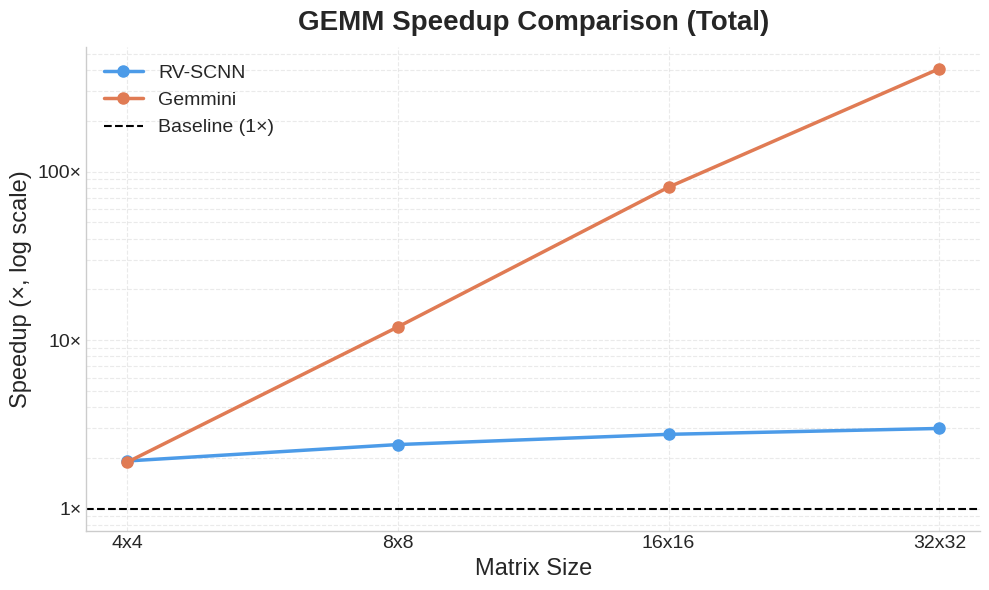

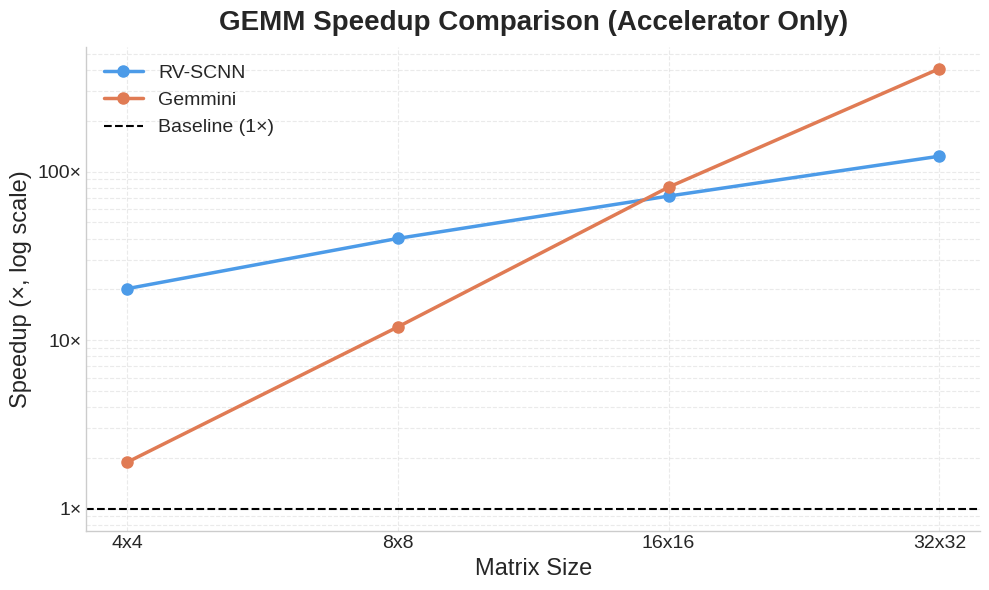

In [29]:
# ── FULL (total) speedup ───────────────────────────────────────────────────────
temp_total = square_gemm[["size", "rvscnn_speedup", "gemmini_speedup"]].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(temp_total["size"], temp_total["rvscnn_speedup"],  color="#4C9BE8", linewidth=2.5, marker="o", markersize=8, label="RV-SCNN")
ax.plot(temp_total["size"], temp_total["gemmini_speedup"], color="#E07B54", linewidth=2.5, marker="o", markersize=8, label="Gemmini")
ax.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Baseline (1×)")
ax.set_title("GEMM Speedup Comparison (Total)", fontsize=FS_TITLE, fontweight="bold", pad=12)
ax.set_xlabel("Matrix Size", fontsize=FS_LABEL)
ax.set_ylabel("Speedup (×, log scale)", fontsize=FS_LABEL)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}×"))
ax.tick_params(labelsize=FS_TICK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4, which="both")
ax.legend(fontsize=FS_LEGEND)
plt.tight_layout()
plt.savefig("figures/square_gemm_speedup_total.png", dpi=150, bbox_inches="tight")
plt.show()

# ── ACCEL-ONLY speedup ────────────────────────────────────────────────────────
temp_accel = square_gemm[["size", "rvscnn_accel_only_speedup", "gemmini_accel_only_speedup"]].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(temp_accel["size"], temp_accel["rvscnn_accel_only_speedup"],  color="#4C9BE8", linewidth=2.5, marker="o", markersize=8, label="RV-SCNN")
ax.plot(temp_accel["size"], temp_accel["gemmini_accel_only_speedup"], color="#E07B54", linewidth=2.5, marker="o", markersize=8, label="Gemmini")
ax.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Baseline (1×)")
ax.set_title("GEMM Speedup Comparison (Accelerator Only)", fontsize=FS_TITLE, fontweight="bold", pad=12)
ax.set_xlabel("Matrix Size", fontsize=FS_LABEL)
ax.set_ylabel("Speedup (×, log scale)", fontsize=FS_LABEL)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}×"))
ax.tick_params(labelsize=FS_TICK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4, which="both")
ax.legend(fontsize=FS_LEGEND)
plt.tight_layout()
plt.savefig("figures/square_gemm_speedup_accel_only.png", dpi=150, bbox_inches="tight")
plt.show()

# Gemm + RVSCNN speedups combined

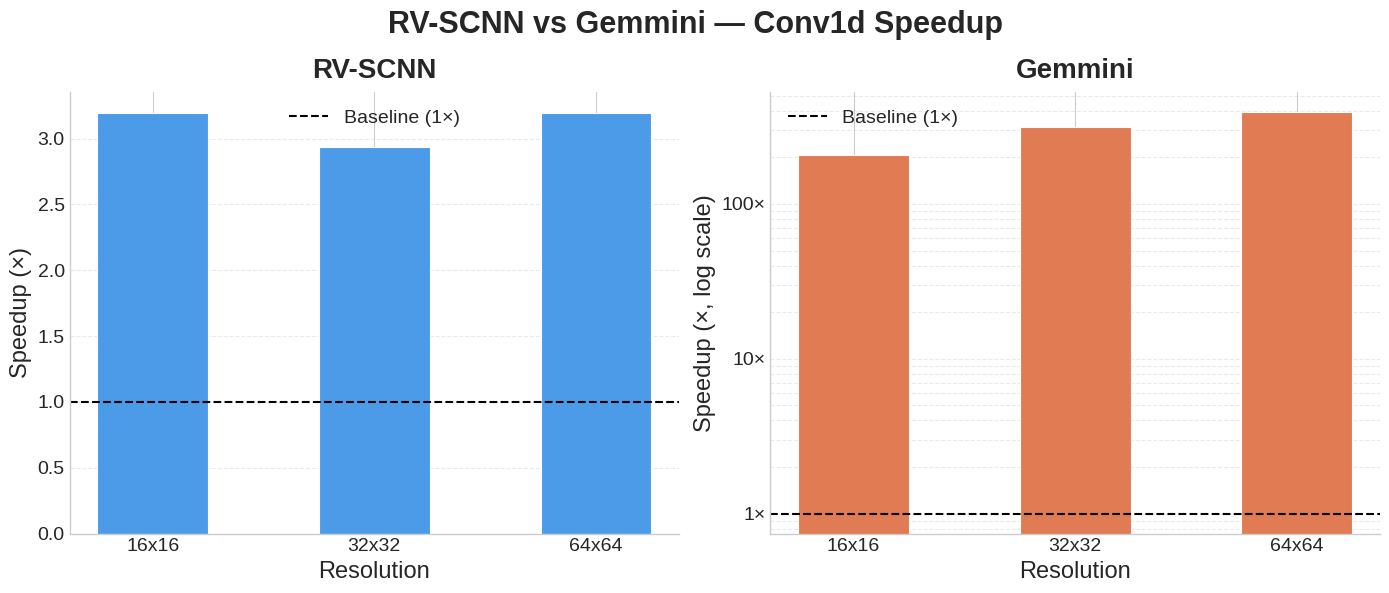

In [30]:
# ── DATAFRAME ────────────────────────────────────────────────────────────────
import pandas as pd

temp_results = results[results["accelerator"].isin(["RV-SCNN", "Gemmini"])][
    ["accelerator", "resolution", "speedup"]
].copy()

# ── GRAPH ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

FS_TITLE  = 20
FS_LABEL  = 17
FS_TICK   = 14
FS_LEGEND = 14

rv_data  = temp_results[temp_results["accelerator"] == "RV-SCNN"]
gem_data = temp_results[temp_results["accelerator"] == "Gemmini"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("RV-SCNN vs Gemmini — Conv1d Speedup", fontsize=22, fontweight="bold")

# ── Left: RV-SCNN ─────────────────────────────────────────────────────────────
ax1.bar(rv_data["resolution"], rv_data["speedup"], color="#4C9BE8",
        width=0.5, edgecolor="white", linewidth=0.8)
ax1.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Baseline (1×)")
ax1.set_title("RV-SCNN", fontsize=FS_TITLE, fontweight="bold", pad=10)
ax1.set_xlabel("Resolution", fontsize=FS_LABEL)
ax1.set_ylabel("Speedup (×)", fontsize=FS_LABEL)
ax1.tick_params(labelsize=FS_TICK)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(fontsize=FS_LEGEND)

# ── Right: Gemmini (log) ──────────────────────────────────────────────────────
ax2.bar(gem_data["resolution"], gem_data["speedup"], color="#E07B54",
        width=0.5, edgecolor="white", linewidth=0.8)
ax2.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Baseline (1×)")
ax2.set_title("Gemmini", fontsize=FS_TITLE, fontweight="bold", pad=10)
ax2.set_xlabel("Resolution", fontsize=FS_LABEL)
ax2.set_ylabel("Speedup (×, log scale)", fontsize=FS_LABEL)
ax2.set_yscale("log")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}×"))
ax2.tick_params(labelsize=FS_TICK)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.4, which="both")
ax2.legend(fontsize=FS_LEGEND)

plt.tight_layout()
plt.savefig("figures/rv_vs_gemmini_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

# Percentages

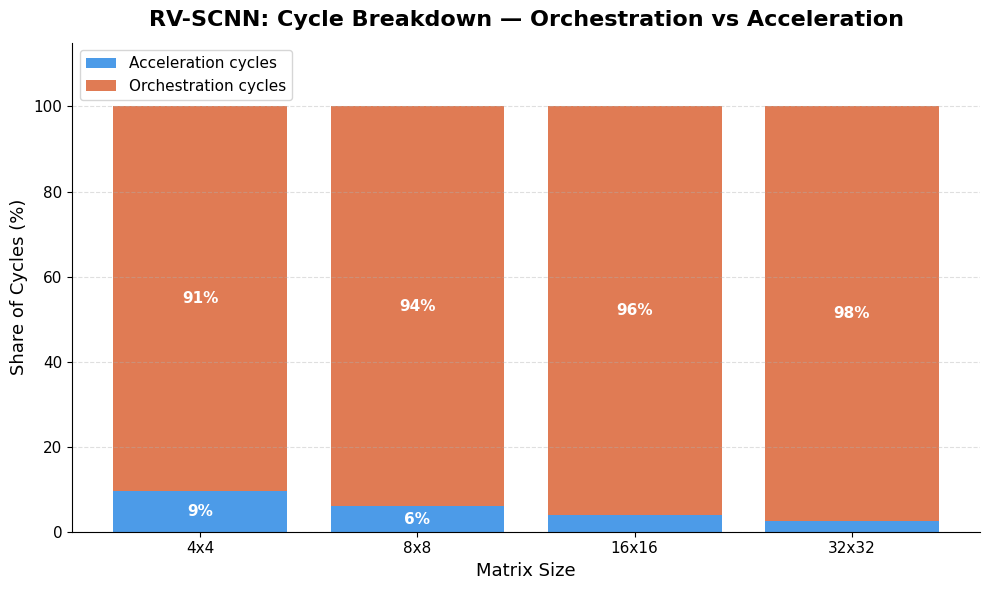

In [10]:
temp_rvscnn = square_gemm[["size", "rvscnn_accel_cycles", "rvscnn_accel_only_cycles"]].copy()
temp_rvscnn["orchestration_cycles"] = temp_rvscnn["rvscnn_accel_cycles"] - temp_rvscnn["rvscnn_accel_only_cycles"]
temp_rvscnn["accel_pct"] = temp_rvscnn["rvscnn_accel_only_cycles"] / temp_rvscnn["rvscnn_accel_cycles"] * 100
temp_rvscnn["orch_pct"] = temp_rvscnn["orchestration_cycles"] / temp_rvscnn["rvscnn_accel_cycles"] * 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(temp_rvscnn["size"], temp_rvscnn["accel_pct"],
       color="#4C9BE8", label="Acceleration cycles")

ax.bar(temp_rvscnn["size"], temp_rvscnn["orch_pct"],
       bottom=temp_rvscnn["accel_pct"],
       color="#E07B54", label="Orchestration cycles")

for i, (acc, orch) in enumerate(zip(temp_rvscnn["accel_pct"], temp_rvscnn["orch_pct"])):
    if acc > 4:
        ax.text(i, acc / 2, f"{acc:.0f}%", ha="center", va="center", fontsize=FS_TICK, fontweight="bold", color="white")
    ax.text(i, acc + orch / 2, f"{orch:.0f}%", ha="center", va="center", fontsize=FS_TICK, fontweight="bold", color="white")

ax.set_title("RV-SCNN: Cycle Breakdown — Orchestration vs Acceleration", fontsize=FS_TITLE, fontweight="bold", pad=12)
ax.set_xlabel("Matrix Size", fontsize=FS_LABEL)
ax.set_ylabel("Share of Cycles (%)", fontsize=FS_LABEL)

# Change: Increased upper limit slightly to prevent the top-left legend from blocking data
ax.set_ylim(0, 115) 

ax.tick_params(labelsize=FS_TICK)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4, axis="y")

# Change: Moved legend to 'upper left'
ax.legend(fontsize=FS_LEGEND, loc="upper left") 

plt.tight_layout()
plt.savefig("figures/rvscnn_cycle_breakdown_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

## MISCELANEOUS

In [2]:
# Assuming data is already loaded based on your previous paths
data_dir = Path("./data")
data_16 = torch.load(data_dir / "darcy_train_16.pt")
data_32 = torch.load(data_dir / "darcy_train_32.pt")

# Set random seed for reproducibility
np.random.seed(42)
sample_idx_16 = np.random.randint(0, data_16['x'].shape[0])
sample_idx_32 = np.random.randint(0, data_32['x'].shape[0])

# Extract sample slices (converting to numpy)
x_16 = data_16['x'][sample_idx_16].numpy()
y_16 = data_16['y'][sample_idx_16].numpy()
x_32 = data_32['x'][sample_idx_32].numpy()
y_32 = data_32['y'][sample_idx_32].numpy()

# Initialize Grid
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# Colormaps matching physical domains
cmap_x = 'twilight_shifted'  # Distinct pattern for permeability coefficients
cmap_y = 'viridis'           # Smooth gradient for pressure fields

# --- Row 1: Darcy 16x16 ---
im1 = axes[0, 0].imshow(x_16, cmap=cmap_x)
axes[0, 0].set_title(f"Darcy 16x16: Input ($x$)\n[Sample #{sample_idx_16}]", fontweight='bold', pad=10)

im2 = axes[0, 1].imshow(y_16, cmap=cmap_y)
axes[0, 1].set_title(f"Darcy 16x16: Fluid Pressure ($y$)\n[Sample #{sample_idx_16}]", fontweight='bold', pad=10)

# --- Row 2: Darcy 32x32 ---
im3 = axes[1, 0].imshow(x_32, cmap=cmap_x)
axes[1, 1].set_title(f"Darcy 32x32: Input ($x$)\n[Sample #{sample_idx_32}]", fontweight='bold', pad=10) # Fixed reference layout

im4 = axes[1, 1].imshow(y_32, cmap=cmap_y)
axes[1, 0].set_title(f"Darcy 32x32: Fluid Pressure ($y$)\n[Sample #{sample_idx_32}]", fontweight='bold', pad=10)

# Formatting Ticks, Gridlines & Labels
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.grid(False)
        # Use cleaner integer ticks matching dimensions
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        
# Add Independent Colorbars dynamically per domain type
cbar_ax_x = fig.add_axes([0.15, 0.05, 0.3, 0.02]) # [left, bottom, width, height]
cbar_x = fig.colorbar(im3, cax=cbar_ax_x, orientation='horizontal')
cbar_x.set_label('Permeability Coefficient ($x$)', fontweight='semibold')

cbar_ax_y = fig.add_axes([0.57, 0.05, 0.3, 0.02])
cbar_y = fig.colorbar(im4, cax=cbar_ax_y, orientation='horizontal')
cbar_y.set_label('Pressure Field Solution ($y$)', fontweight='semibold')

# Layout Tuning
plt.subplots_adjust(bottom=0.15, hspace=0.35, wspace=0.25)
fig.suptitle("Darcy Flow Dataset Sub-Sample Formats", y=0.98, fontsize=15, fontweight='bold')

plt.show()

NameError: name 'np' is not defined